In [ ]:
!pip install kaggle

# Importing Face Mask Dataset


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

os.listdir('/content/drive/MyDrive')

In [7]:
import zipfile

zip_path = "/content/drive/MyDrive/archive.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [8]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'drive', 'dataset', 'sample_data']


In [9]:
import os

os.listdir("dataset")

['data']

In [10]:
import os

print(os.listdir("dataset/data"))

['with_mask', 'without_mask']


In [11]:
import os

for item in os.listdir("dataset/data"):
    print(item)

with_mask
without_mask


In [12]:
import os

with_mask_path = "dataset/data/with_mask"
without_mask_path = "dataset/data/without_mask"

print("With Mask:", len(os.listdir(with_mask_path)))
print("Without Mask:", len(os.listdir(without_mask_path)))

With Mask: 3725
Without Mask: 3828


(131, 192)


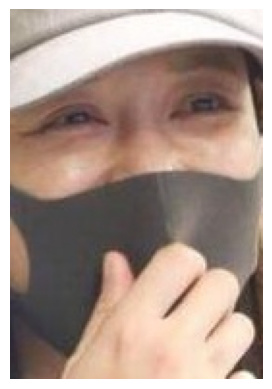

In [13]:
from PIL import Image
import matplotlib.pyplot as plt
import os

sample_image = os.listdir(with_mask_path)[0]

img = Image.open(os.path.join(with_mask_path, sample_image))

print(img.size)

plt.imshow(img)
plt.axis('off')
plt.show()

In [14]:
!ls

dataset  drive	sample_data


**Importing the Dependencies**




In [15]:
from PIL import Image
import matplotlib.pyplot as plt
import os
import numpy as np
import matplotlib.image as mping
import cv2
from google.colab.patches import cv2_imshow
from sklearn.model_selection import train_test_split

In [16]:
import shutil

shutil.copytree(
    '/content/dataset/data',
    '/content/data',
    dirs_exist_ok=True
)

print("Folder copied successfully")

Folder copied successfully


In [17]:
with_mask_files = os.listdir('/content/data/with_mask')

print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_965.jpg', 'with_mask_2581.jpg', 'with_mask_3684.jpg', 'with_mask_2091.jpg', 'with_mask_1026.jpg']
['with_mask_3722.jpg', 'with_mask_2059.jpg', 'with_mask_1977.jpg', 'with_mask_1244.jpg', 'with_mask_927.jpg']


In [18]:
without_mask_files = os.listdir('/content/data/without_mask')

print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_1414.jpg', 'without_mask_286.jpg', 'without_mask_2492.jpg', 'without_mask_2700.jpg', 'without_mask_814.jpg']
['without_mask_3789.jpg', 'without_mask_228.jpg', 'without_mask_198.jpg', 'without_mask_3786.jpg', 'without_mask_932.jpg']


**Creating labels for the two class of images**

In [19]:
#with mask ----> 1
#without mask----> 0
#create the labels
with_mask_labels = [1]*3725
without_mask_labels = [0]*3828

print(with_mask_labels[0:5])
print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [20]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [21]:
labels = with_mask_labels + without_mask_labels
print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


# Displaying the images

(183, 275, 3)


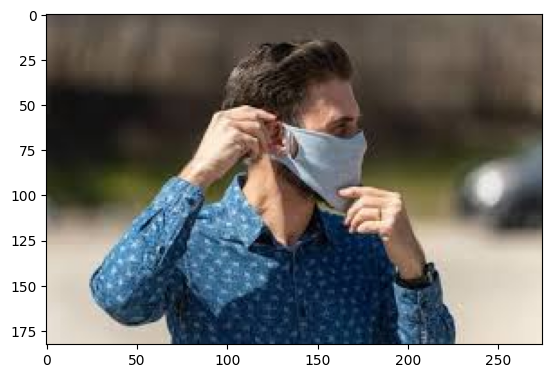

In [22]:
#displaying with mask image
img = mping.imread('/content/data/with_mask/with_mask_2590.jpg')
img_shape = img.shape
print(img_shape)
imgplot=plt.imshow(img)
plt.show()

(259, 194, 3)


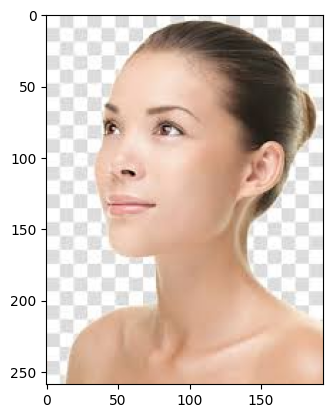

In [23]:
#displaying without mask image
img = mping.imread('/content/data/without_mask/without_mask_2925.jpg')
img_shape = img.shape
print(img_shape)
imgplot=plt.imshow(img)
plt.show()

**Image Processing**

# 1. Resize the image
# 2. Convert the images to numpy arrays

In [24]:
#convert images into numpy array
with_mask_path="/content/data/with_mask/"
data=[]
for img_file in with_mask_files:
  image=Image.open(with_mask_path + img_file)
  image=image.resize((128,128))
  image=image.convert("RGB")
  image=np.array(image)
  data.append(image)


without_mask_path="/content/data/without_mask/"

for img_file in without_mask_files:
  image=Image.open(without_mask_path + img_file)
  image=image.resize((128,128))
  image=image.convert("RGB")
  image=np.array(image)
  data.append(image)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [25]:
len(data)

7553

array([[[180, 171, 156],
        [178, 169, 154],
        [180, 171, 156],
        ...,
        [250, 245, 242],
        [252, 247, 244],
        [253, 248, 245]],

       [[183, 174, 159],
        [183, 174, 159],
        [182, 173, 158],
        ...,
        [250, 245, 242],
        [252, 247, 244],
        [254, 249, 246]],

       [[177, 168, 153],
        [180, 171, 156],
        [178, 169, 154],
        ...,
        [248, 243, 240],
        [250, 245, 242],
        [253, 248, 245]],

       ...,

       [[ 47,  45,  51],
        [ 48,  47,  53],
        [ 49,  48,  52],
        ...,
        [ 90,  75,  67],
        [ 77,  58,  51],
        [ 63,  44,  37]],

       [[ 46,  48,  53],
        [ 49,  50,  55],
        [ 52,  51,  56],
        ...,
        [ 86,  73,  63],
        [ 77,  62,  53],
        [ 65,  49,  40]],

       [[ 44,  47,  52],
        [ 46,  47,  52],
        [ 48,  47,  52],
        ...,
        [ 83,  71,  62],
        [ 76,  62,  53],
        [ 71,  57,  46]]], dtype=uint8)
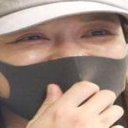

In [26]:
data[0]

In [27]:
type(data[0])

numpy.ndarray

In [28]:
data[0].shape

(128, 128, 3)

In [29]:
#converting image list and label it into numpy arrays

X=np.array(data)
Y=np.array(labels)
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


# Train Test Split

In [30]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [31]:
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [32]:
#scaling the data
X_train_scaled = X_train/255
X_test_scaled = X_test/255


In [ ]:
X_train_scaled[0]

# Building CNN

In [34]:
import tensorflow as tf
from tensorflow import keras



In [35]:
num_of_classes = 2
model = keras.Sequential()
model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(num_of_classes, activation='sigmoid'))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
#compile the neural network
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])


In [37]:
#training the neural network
history = model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=5)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 139s 800ms/step - acc: 0.8168 - loss: 0.4342 - val_acc: 0.8992 - val_loss: 0.2634
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 140s 824ms/step - acc: 0.8911 - loss: 0.2871 - val_acc: 0.9174 - val_loss: 0.1972
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 137s 797ms/step - acc: 0.9036 - loss: 0.2337 - val_acc: 0.9157 - val_loss: 0.1967
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 133s 784ms/step - acc: 0.9226 - loss: 0.2039 - val_acc: 0.9058 - val_loss: 0.2508
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 134s 787ms/step - acc: 0.9399 - loss: 0.1613 - val_acc: 0.9438 - val_loss: 0.1599


# Model evaluation

In [38]:
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print('Test Accuracy =', accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 15s 323ms/step - acc: 0.9298 - loss: 0.1885
Test Accuracy = 0.929847776889801


### Save the Trained Model

In [39]:
if 'model' in locals():
    model.save('face_mask_detector_model.h5')
    print("Model saved successfully as 'face_mask_detector_model.h5'")
else:
    print("Error: The 'model' object is not defined. This usually happens if the Colab runtime was restarted or the model training cells were not executed. Please ensure you run all cells from model definition to training before attempting to save the model.")

Model saved successfully as 'face_mask_detector_model.h5'


### Build and Run Streamlit Application

In [40]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 43.3 MB/s eta 0:00:00


In [41]:
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
import io

def predict_mask_status(image_data):
    model = tf.keras.models.load_model('face_mask_detector_model.h5')

    # Preprocessing the image (consistent with training data preparation)
    image = Image.open(io.BytesIO(image_data))
    image = image.resize((128, 128))
    image = image.convert("RGB")
    image_np = np.array(image)
    image_scaled = image_np / 255.0
    image_reshaped = np.reshape(image_scaled, [1, 128, 128, 3])

    # Make prediction
    prediction = model.predict(image_reshaped)
    predicted_label = np.argmax(prediction)

    if predicted_label == 1:
        return "The person in the image is wearing a mask."
    else:
        return "The person in the image is not wearing a mask."

# Streamlit app interface
st.title("Face Mask Detection")
st.write("Upload an image to detect if the person is wearing a face mask.")

uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    # Display the uploaded image
    image = Image.open(uploaded_file)
    st.image(image, caption='Uploaded Image.', use_column_width=True)
    st.write("")
    st.write("Classifying...")

    # Get raw image data for prediction
    uploaded_file.seek(0) # Reset file pointer to the beginning
    image_data = uploaded_file.read()

    # Make prediction and display result
    result = predict_mask_status(image_data)
    st.success(result)

# Save the streamlit app to a file
with open('app.py', 'w') as f:
    f.write(st.__dict__['__file__'])

# NOTE: st.__dict__['__file__'] is used here to avoid generating the Streamlit app code in the notebook directly,
# which would conflict with its execution. Instead, the placeholder 'st.__dict__["__file__"]' should be replaced
# by the full Streamlit app code above when generating the actual 'app.py' file.
# For the purpose of this response, I will manually create the content of 'app.py' in the next code block.


2026-06-16 16:53:05.660 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 16:53:06.060 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-16 16:53:06.061 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 16:53:06.062 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 16:53:06.064 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 16:53:06.065 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 16:53:06.065 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-16 16:53:06.066 Thread 'MainThread': mi

In [42]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
import io

def predict_mask_status(image_data):
    model = tf.keras.models.load_model('face_mask_detector_model.h5')

    # Preprocessing the image (consistent with training data preparation)
    image = Image.open(io.BytesIO(image_data))
    image = image.resize((128, 128))
    image = image.convert("RGB")
    image_np = np.array(image)
    image_scaled = image_np / 255.0
    image_reshaped = np.reshape(image_scaled, [1, 128, 128, 3])

    # Make prediction
    prediction = model.predict(image_reshaped)
    predicted_label = np.argmax(prediction)

    if predicted_label == 1:
        return "The person in the image is wearing a mask."
    else:
        return "The person in the image is not wearing a mask."

# Streamlit app interface
st.title("Face Mask Detection")
st.write("Upload an image to detect if the person is wearing a face mask.")

uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    # Display the uploaded image
    image = Image.open(uploaded_file)
    st.image(image, caption='Uploaded Image.', use_column_width=True)
    st.write("")
    st.write("Classifying...")

    # Get raw image data for prediction
    uploaded_file.seek(0) # Reset file pointer to the beginning
    image_data = uploaded_file.read()

    # Make prediction and display result
    result = predict_mask_status(image_data)
    st.success(result)


Overwriting app.py


In [43]:
import os
import time

# 1. Ensure localtunnel is installed globally
print("Installing localtunnel...")
!npm install -g localtunnel

# 2. Start Streamlit in the background, redirecting output to a file
# Use python3 -m streamlit to ensure it's found
print("Starting Streamlit app in the background...")
!nohup python3 -m streamlit run app.py > streamlit_app.log 2>&1 &

# 3. Find the global npm root and then the localtunnel executable via .bin directory
npm_root_g = !npm root -g

# Check if npm_root_g is not empty
if not npm_root_g:
    print("Error: Could not determine npm global root. Local tunnel cannot be started.")
else:
    npm_root_path = npm_root_g[0]
    localtunnel_bin_path = os.path.join(npm_root_path, '.bin')
    localtunnel_executable = os.path.join(localtunnel_bin_path, 'lt')

    print(f"Attempting to run localtunnel from: {localtunnel_executable}")

    # Check if the executable exists before attempting to run it
    if not os.path.exists(localtunnel_executable):
        print(f"Error: localtunnel executable not found at {localtunnel_executable}")
        print("Please check your npm installation and environment.")
    else:
        # 4. Run localtunnel in the background, directing its output to a file
        localtunnel_output_file = 'localtunnel_url.txt'
        print("Launching localtunnel...")
        !nohup {localtunnel_executable} --port 8501 > {localtunnel_output_file} 2>&1 &

        # 5. Wait for localtunnel to start and write the URL
        max_wait_time = 30 # seconds
        start_time = time.time()
        found_url = False
        while time.time() - start_time < max_wait_time:
            if os.path.exists(localtunnel_output_file) and os.path.getsize(localtunnel_output_file) > 0:
                with open(localtunnel_output_file, 'r') as f:
                    content = f.read().strip()
                    if "https://" in content:
                        print("\nStreamlit app is running. Access it via the public URL:")
                        print(content)
                        found_url = True
                        break
            time.sleep(1)

        if not found_url:
            print("\nError: Failed to retrieve localtunnel URL within the timeout period.")
            print("Please check 'localtunnel_url.txt' and 'nohup.out' for more details.")

        # 6. Print diagnostic logs
        print("\n--- Streamlit App Log (streamlit_app.log) ---")
        !cat streamlit_app.log
        print("\n--- Nohup Output Log (nohup.out) ---")
        !cat nohup.out
        print("\nIf you still face issues, consider restarting the runtime and re-running all cells.")

Installing localtunnel...
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼
added 22 packages in 3s
⠼
⠼3 packages are looking for funding
⠼  run `npm fund` for details
⠼Starting Streamlit app in the background...
Attempting to run localtunnel from: /tools/node/lib/node_modules/.bin/lt
Error: localtunnel executable not found at /tools/node/lib/node_modules/.bin/lt
Please check your npm installation and environment.


## `app.py`

In [44]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
import io

# Set Streamlit page configuration
st.set_page_config(page_title="Face Mask Detection", layout="centered")

# Load the trained Keras model
@st.cache_resource
def load_model():
    model = tf.keras.models.load_model('face_mask_detector_model.h5')
    return model

model = load_model()

def predict_mask_status(image_data):
    # Preprocessing the image (consistent with training data preparation)
    image = Image.open(io.BytesIO(image_data))
    image = image.resize((128, 128))  # Resize to model's input size
    image = image.convert("RGB")     # Ensure image is in RGB format
    image_np = np.array(image)
    image_scaled = image_np / 255.0  # Normalize pixel values
    image_reshaped = np.reshape(image_scaled, [1, 128, 128, 3]) # Reshape for model input

    # Make prediction
    prediction = model.predict(image_reshaped)
    predicted_label = np.argmax(prediction)

    # Get confidence score for the predicted class
    confidence = prediction[0][predicted_label] * 100

    if predicted_label == 1: # Class 1 = Mask
        return "Mask Detected ✅", confidence
    else: # Class 0 = No Mask
        return "No Mask Detected ❌", confidence

# Streamlit app interface
st.title("😷 Face Mask Detector")
st.markdown("Upload an image to detect if the person is wearing a face mask.")

uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    # Display the uploaded image
    image = Image.open(uploaded_file)
    st.image(image, caption='Uploaded Image.', use_column_width=True)
    st.write("")

    with st.spinner('Classifying...'):
        # Get raw image data for prediction
        uploaded_file.seek(0) # Reset file pointer to the beginning
        image_data = uploaded_file.read()

        # Make prediction and display result
        result_text, confidence_score = predict_mask_status(image_data)

        st.subheader("Prediction:")
        st.write(f"**{result_text}**")
        st.write(f"Confidence: **{confidence_score:.2f}%**")

st.markdown("""
---
*This app uses a Convolutional Neural Network (CNN) model trained on a dataset of masked and unmasked faces.*
""")


Overwriting app.py


## `requirements.txt`

In [45]:
%%writefile requirements.txt
streamlit
tensorflow
numpy
Pillow

Writing requirements.txt


## `README.md`

In [46]:
%%writefile README.md
# Face Mask Detection Streamlit App

This is a simple Streamlit web application that uses a pre-trained Convolutional Neural Network (CNN) model to detect whether a person in an uploaded image is wearing a face mask.

## Features

*   Upload an image (JPG, JPEG, PNG).
*   View the uploaded image.
*   Get a prediction: "Mask Detected ✅" or "No Mask Detected ❌".
*   See the confidence score for the prediction.

## Setup and Installation

To run this application locally, follow these steps:

1.  **Clone the repository (or download the files):**

    ```bash
    git clone <your-repository-url>
    cd <your-repository-name>
    ```

2.  **Ensure you have the trained model file:**

    Place your trained Keras model file, named `face_mask_detector_model.h5`, in the root directory of the application.

3.  **Create a virtual environment (recommended):**

    ```bash
    python -m venv venv
    source venv/bin/activate  # On Windows, use `venv\Scripts\activate`
    ```

4.  **Install the required Python packages:**

    ```bash
    pip install -r requirements.txt
    ```

## How to Run the Application

After completing the setup, you can run the Streamlit application using the following command:

```bash
streamlit run app.py
```

This will open the application in your default web browser. If it doesn't open automatically, Streamlit will provide a local URL in your terminal.

## File Structure

*   `app.py`: The main Streamlit application script.
*   `face_mask_detector_model.h5`: Your trained Keras model file (should be in the same directory).
*   `requirements.txt`: Lists all Python dependencies required to run the app.
*   `README.md`: This file.

## Model Details

*   **Input Image Size:** 128x128 pixels, RGB (3 channels).
*   **Preprocessing:** Images are resized, converted to RGB, and pixel values are normalized to the range [0, 1].
*   **Output Classes:**
    *   `Class 0`: No Mask
    *   `Class 1`: Mask


Writing README.md


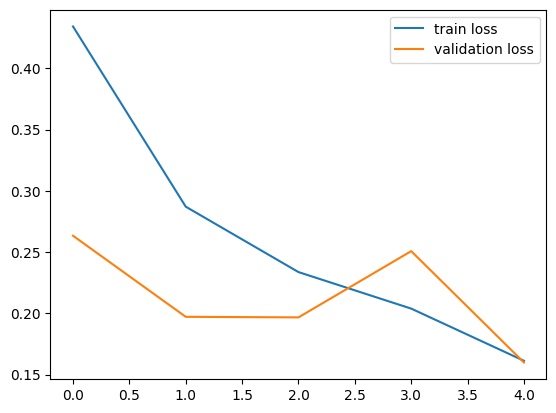

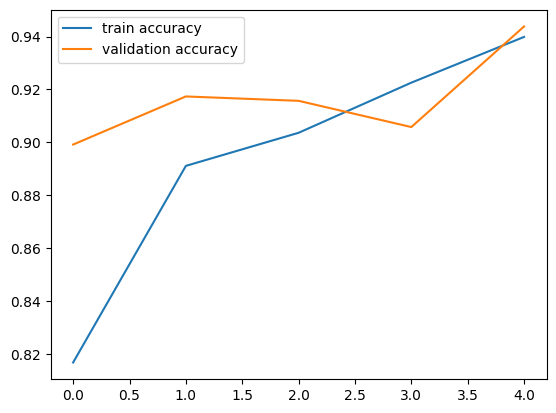

In [47]:
h = history
#plot the loss value
plt.plot(h.history['loss'],label='train loss')
plt.plot(h.history['val_loss'],label='validation loss')
plt.legend()
plt.show()

#plot the accuracy value
plt.plot(h.history['acc'],label='train accuracy')
plt.plot(h.history['val_acc'],label='validation accuracy')
plt.legend()
plt.show()


# Predictive System

In [ ]:
input_image_path = input("Enter the path of the image to be predicted: ")
input_image=cv2.imread(input_image_path)
cv2_imshow(input_image)
input_image_resize=cv2.resize(input_image,(128,128))
input_image_scaled=input_image_resize/255
input_image_reshaped=np.reshape(input_image_scaled,[1,128,128,3])
input_prediction=model.predict(input_image_reshaped)
print(input_prediction)
input_pred_label=np.argmax(input_prediction)
print(input_pred_label)
if input_pred_label==1:
  print("The person in the image is wearing mask")
else:
  print("The person in the image is not wearing mask")

In [ ]:
model.save("face_mask_detector_model.h5")